# Three Steps MultiFidelity Neural Network

come 3NN ma post HPO

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from keras.models import save_model
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
# import of the discretization

file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)


In [4]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)


In [5]:
########################     NORMALIZATION  #########################
# Input
reaction_HF_test=normalization(reaction_HF_test)

In [6]:
NepoLF = 500  # number of epochs for first NN: NN_LF
NepoLin = 1500
NepoHF = 1000 # number of epochs for second NN: NN_HF 
Nlf=100
n_HF = 10

In [7]:
permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:n_HF]

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(8*np.pi*reaction_HF[:, 0]))]
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]

U_HF_test = U_HF_test[-1, :, 44,44]
U_HF_test = normalization(U_HF_test)
U_HF = U_HF_test[permutation][0:n_HF]


In [8]:
U_LF_list = []
U_Lin_list = []
U_HF_list = []

#######
diffusion=[5]
#######


r2_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])


## Neural Network
Cycle on the Discretization and the value of the diffusion

********************  # Nb. nodes = 0  ********************
********************  # Diff: = 5  ********************


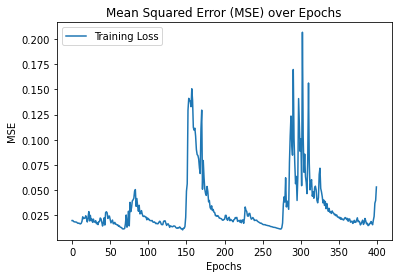

26/26 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.07309903392081872
R^2: 0.24909781684291799
1/1 [==============================] - 0s 31ms/step


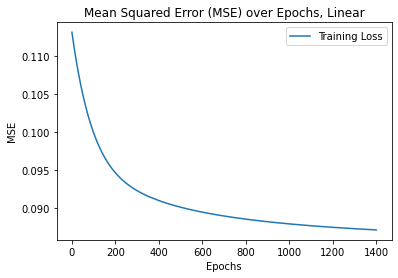

26/26 [==============================] - 0s 2ms/step


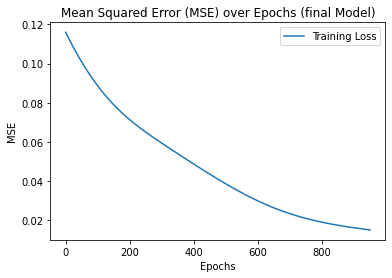

26/26 [==============================] - 0s 2ms/step
Elapsed time:  33.249242099933326
26/26 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.10705294994114031
R^2: 0.004254317560448695

HF Model:
Test MSE: 0.0705864123643114
R^2: 0.34344531944887613
26/26 [==============================] - 0s 1ms/step


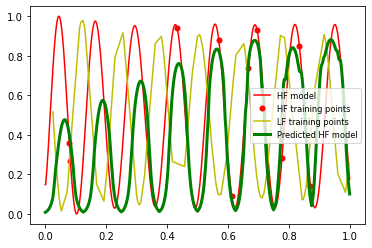

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(

********************  # Nb. nodes = 5  ********************
********************  # Diff: = 5  ********************


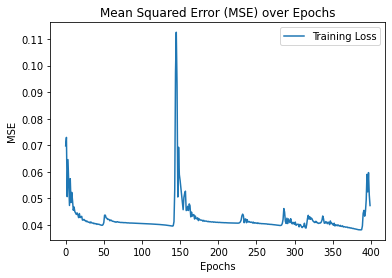

3/3 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.05696788311303879
R^2: 0.457326489240956
1/1 [==============================] - 0s 16ms/step


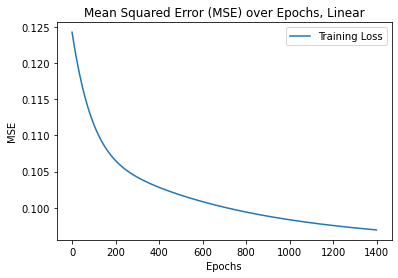

26/26 [==============================] - 0s 2ms/step


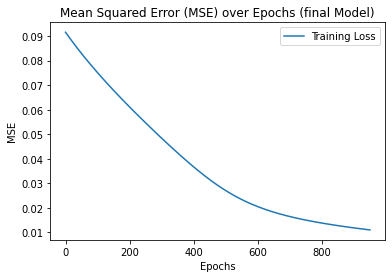

26/26 [==============================] - 0s 3ms/step
Elapsed time:  26.6766520999372
26/26 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.16441345477983788
R^2: -0.5292804899071621

HF Model:
Test MSE: 0.07871828899833261
R^2: 0.2678072258427707
26/26 [==============================] - 0s 4ms/step


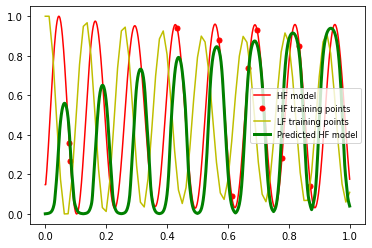

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************


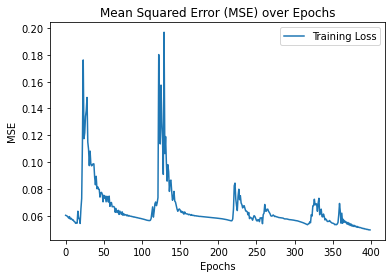

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.04925187947141889
R^2: 0.5448821470994574
1/1 [==============================] - 0s 17ms/step


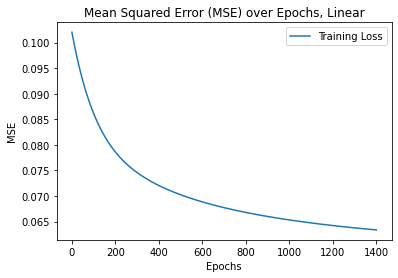

26/26 [==============================] - 0s 2ms/step


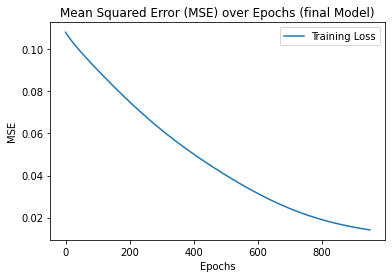

26/26 [==============================] - 0s 2ms/step
Elapsed time:  29.5158333000727
26/26 [==============================] - 0s 1ms/step

Lin Model:
Test MSE: 0.1365549487364343
R^2: -0.27015650381254996

HF Model:
Test MSE: 0.04240751677874873
R^2: 0.6055493869282527
26/26 [==============================] - 0s 1ms/step


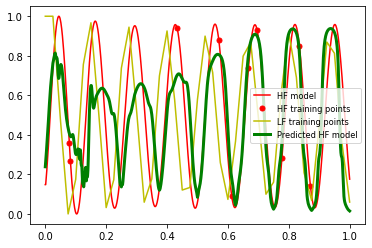

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(

********************  # Nb. nodes = 50  ********************
********************  # Diff: = 5  ********************


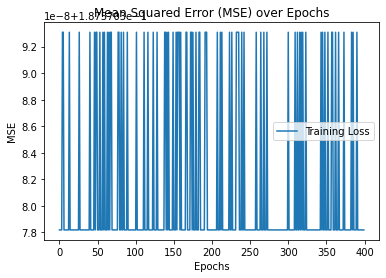

1/1 [==============================] - 0s 112ms/step

LF Model:
Test MSE: 0.18757037744124994
R^2: -0.7391777518897427
1/1 [==============================] - 0s 35ms/step


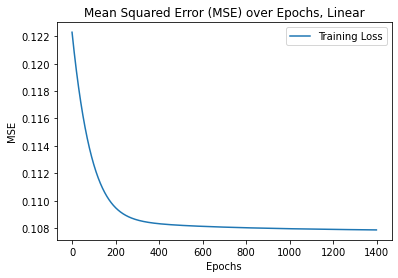

26/26 [==============================] - 0s 2ms/step


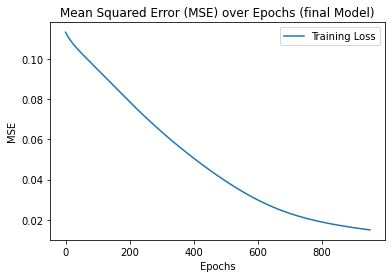

26/26 [==============================] - 0s 2ms/step
Elapsed time:  25.430424300022423
26/26 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.1102751437706679
R^2: -0.02571669767546525

HF Model:
Test MSE: 0.06815180560734507
R^2: 0.3660906474666493
26/26 [==============================] - 0s 2ms/step


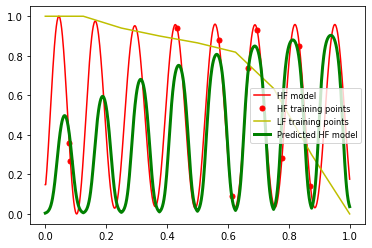

   Discretization Diffusion       R2  diffusion
0             0.0       NaN  0.34345        5.0
1             5.0       NaN  0.26781        5.0
2            10.0       NaN  0.60555        5.0
3            50.0       NaN  0.36609        5.0
   Discretization Diffusion      MSE  diffusion
0             0.0       NaN  0.07059        5.0
1             5.0       NaN  0.07872        5.0
2            10.0       NaN  0.04241        5.0
3            50.0       NaN  0.06815        5.0


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_27644\2135121440.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(

In [9]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")
        (reaction_LF_test, U_LF_test) = import_data(file_name)
        
        U_LF_test = U_LF_test[
        -1,
        :,
        44,44
        ]
       
        reaction_LF_test=normalization(reaction_LF_test)
        U_LF_test=normalization(U_LF_test)
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_train_LF = U_LF_test[permutation][0:Nlf]

        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(8*np.pi*reaction_LF[:, 0]))]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(8*np.pi*reaction_LF_test[:, 0]))]
        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
 
        test_mse_HF_list = []
        test_mse_LF_list = []
        test_mse_Lin_list = []

        r2_HF_list = []
        r2_LF_list = []
        r2_Lin_list = []
        
       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()
        
        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )
        plt.plot(modelLin.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs, Linear')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1), reaction_help1.reshape(-1,1)),axis=1
        )

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1), reaction_test_help1.reshape(-1,1)),axis=1
        )

        name = "3step"
        
        ######################################
        MAX_EVAL = 2

        K.clear_session()
        # best parameters obtained by HPO:
        
        best_params={'kernel_init': 'glorot_uniform', 'l2weight': 0.00026031371862305004, 'lr': 0.0005259986556282031, 'nodes': 26.0, 'opt': 'Adamax'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=20,
            verbose=0,
        )
        plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()
        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "ro",
        markersize=5,
        label="HF training points",
        )
        
        
        order=np.argsort(reaction_LF[:,0])
        plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g-",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
    
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}
        r2_Lin_df=r2_Lin_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_Lin_list[-1]}
        mse_Lin_df=mse_Lin_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
            

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Save the output

In [10]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_5000_1500_3000_new")

r2_HF_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_5000_1500_3000_new/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")